point29mbar_AIstream_0.h5
point29mbar_AIstream_1.h5
point29mbar_AIstream_10.h5
point29mbar_AIstream_11.h5
point29mbar_AIstream_12.h5
point29mbar_AIstream_13.h5
point29mbar_AIstream_14.h5
point29mbar_AIstream_15.h5
point29mbar_AIstream_16.h5
point29mbar_AIstream_17.h5
point29mbar_AIstream_18.h5
point29mbar_AIstream_19.h5
point29mbar_AIstream_2.h5
point29mbar_AIstream_3.h5
point29mbar_AIstream_4.h5
point29mbar_AIstream_5.h5
point29mbar_AIstream_6.h5
point29mbar_AIstream_7.h5
point29mbar_AIstream_8.h5
point29mbar_AIstream_9.h5


c:\Users\Ben\anaconda3\Lib\site-packages\scipy\signal\_spectral_py.py:600: UserWarning: nperseg = 10000 is greater than input length  = 9999, using nperseg = 9999
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


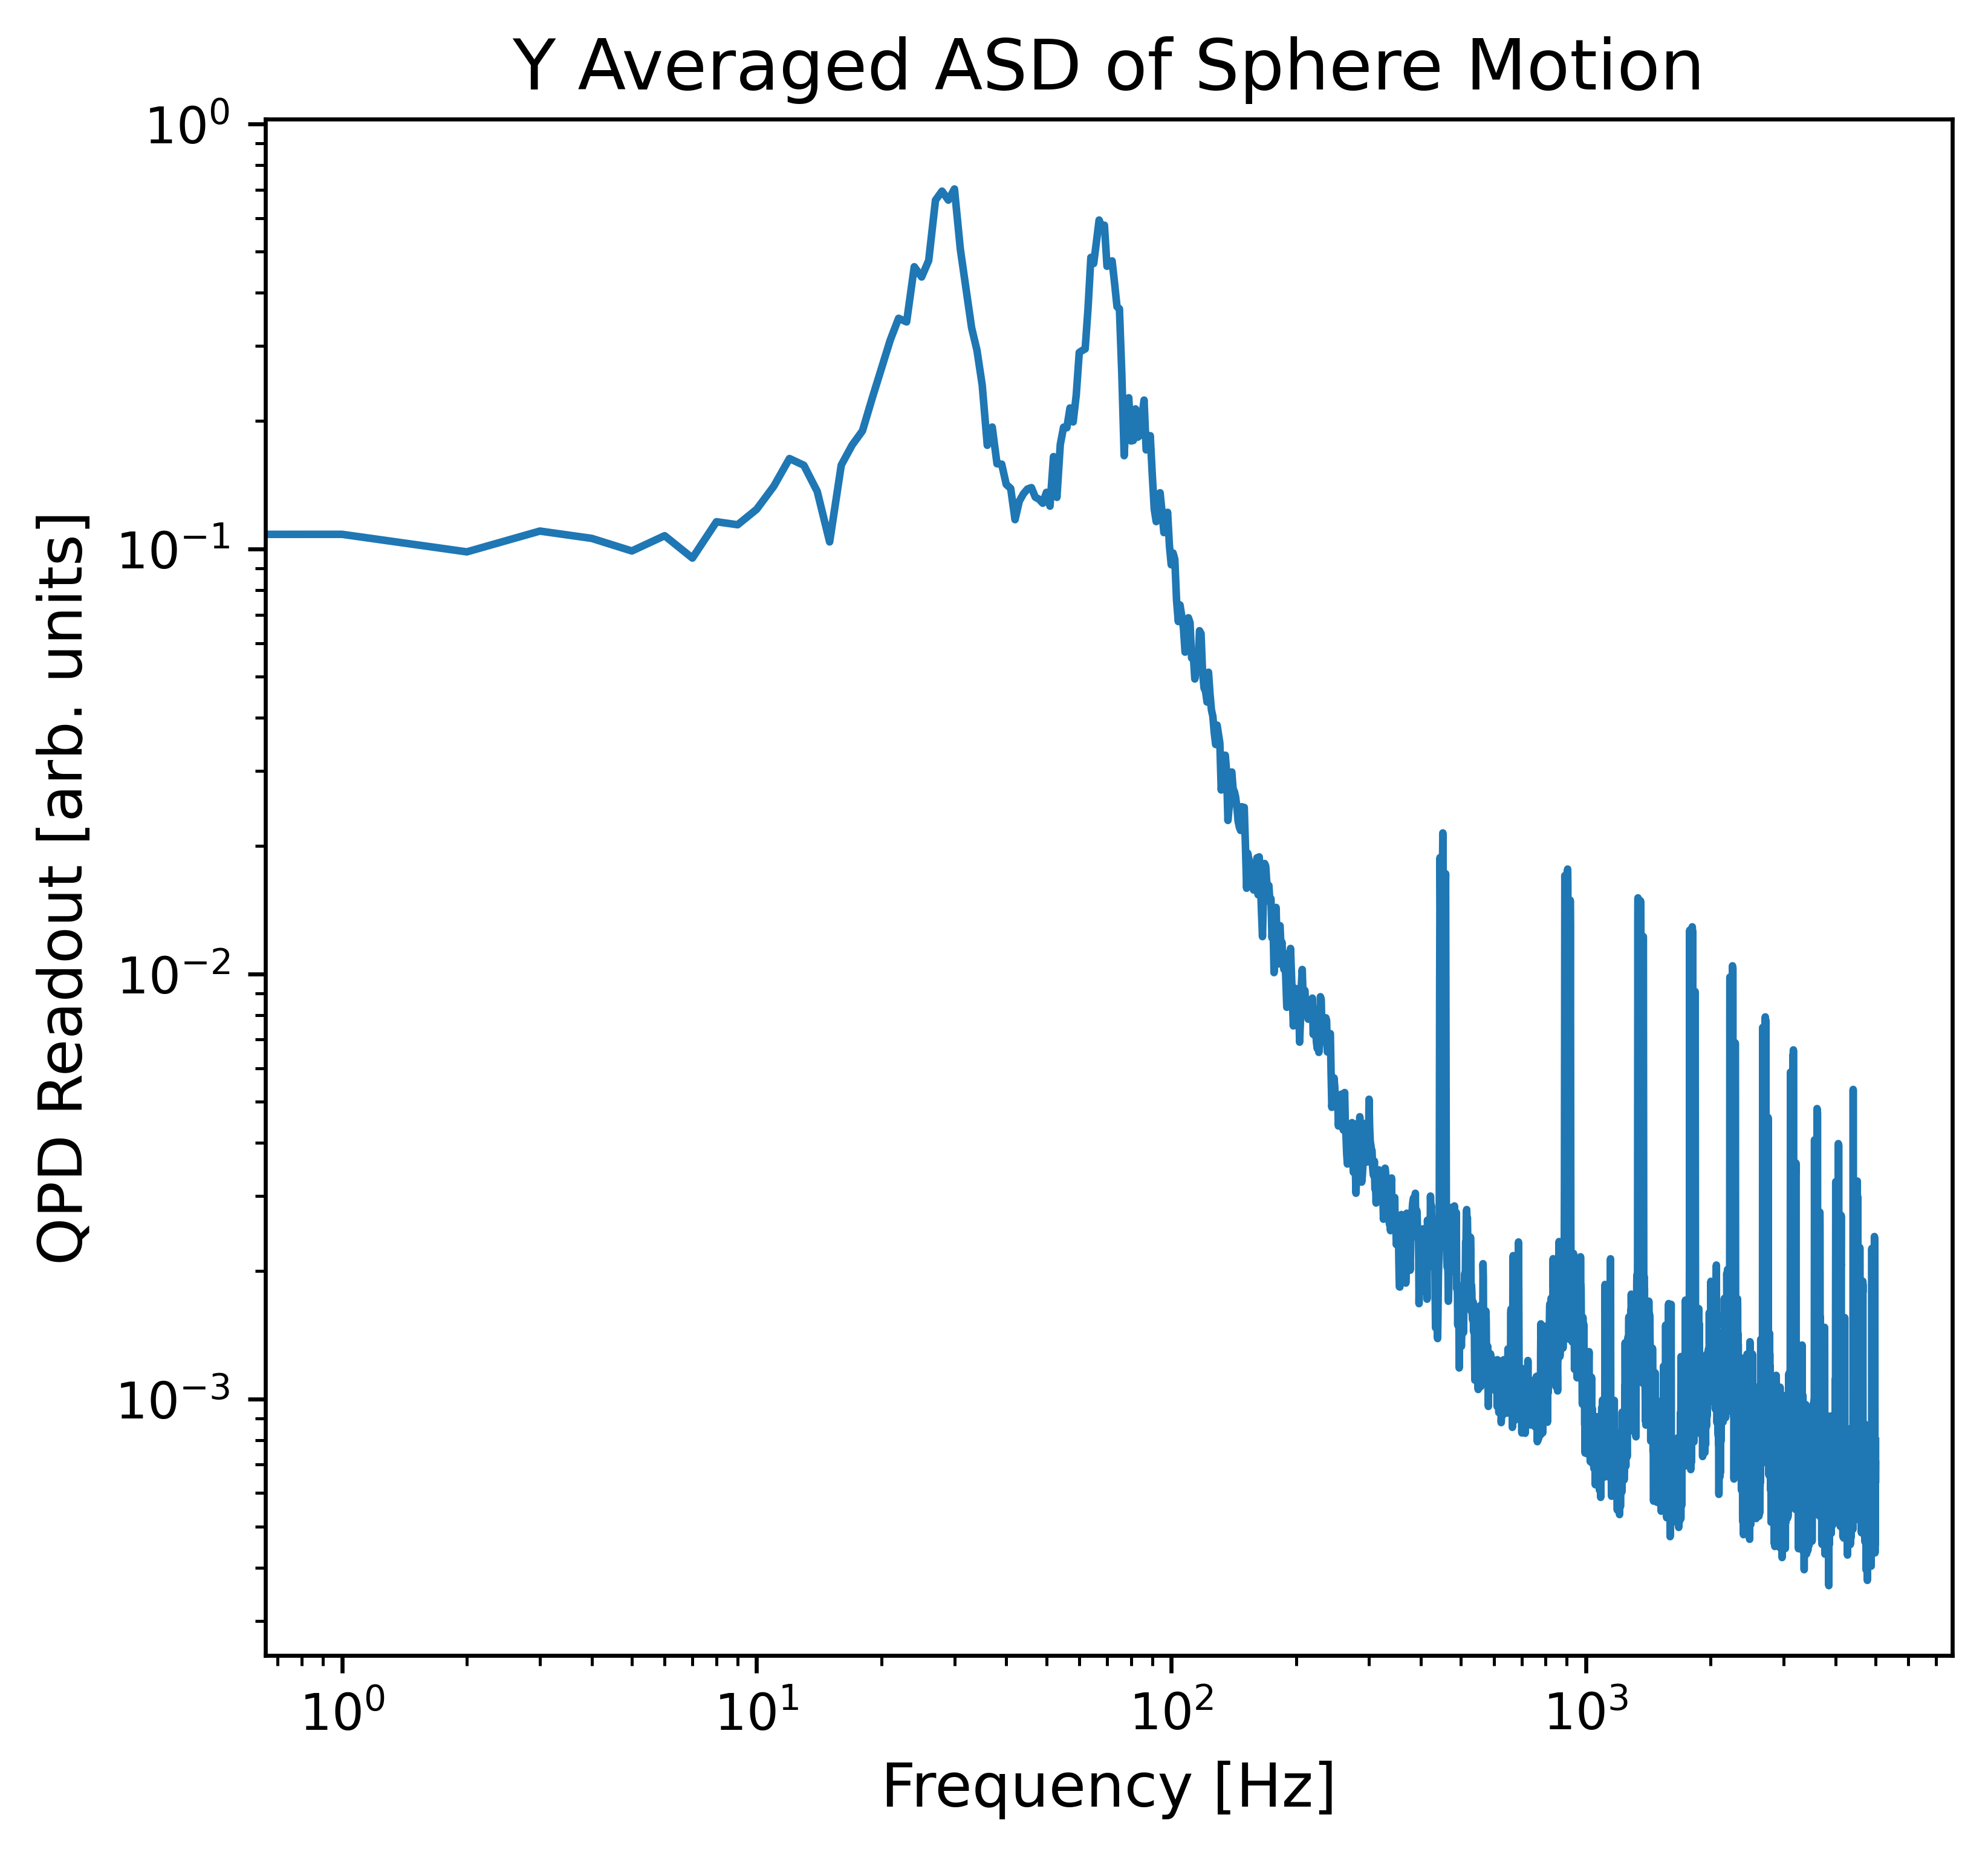

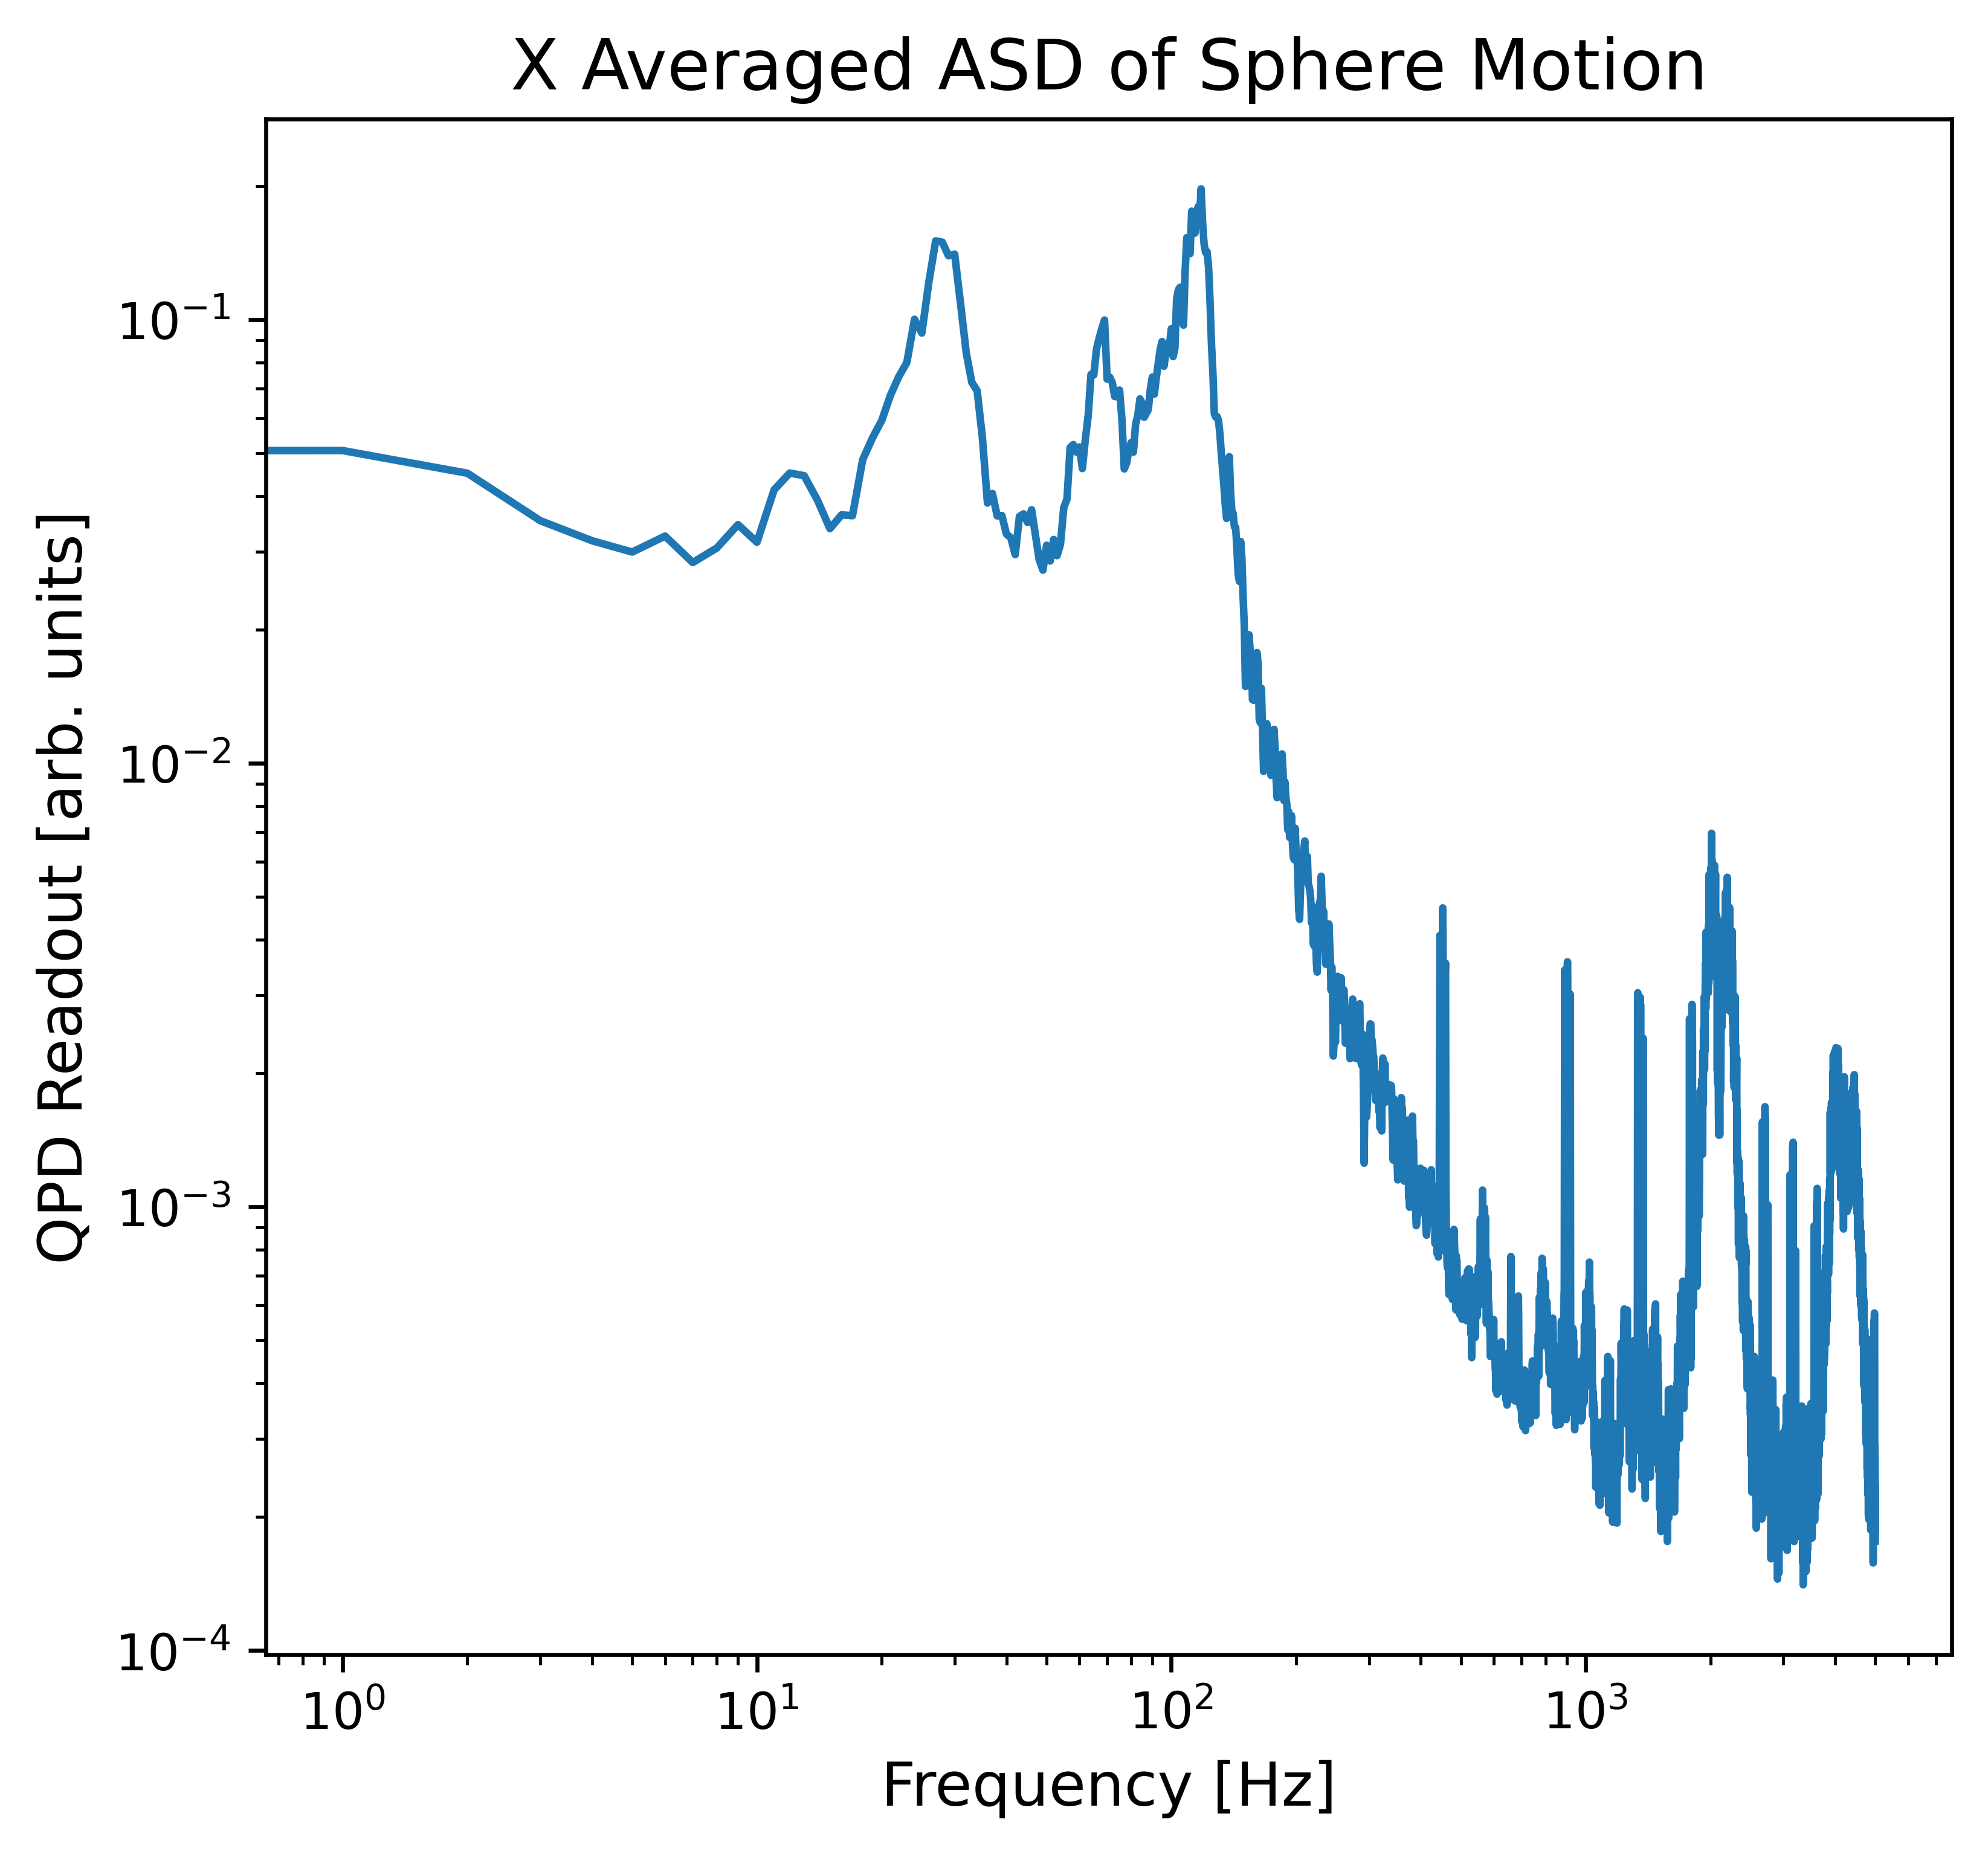

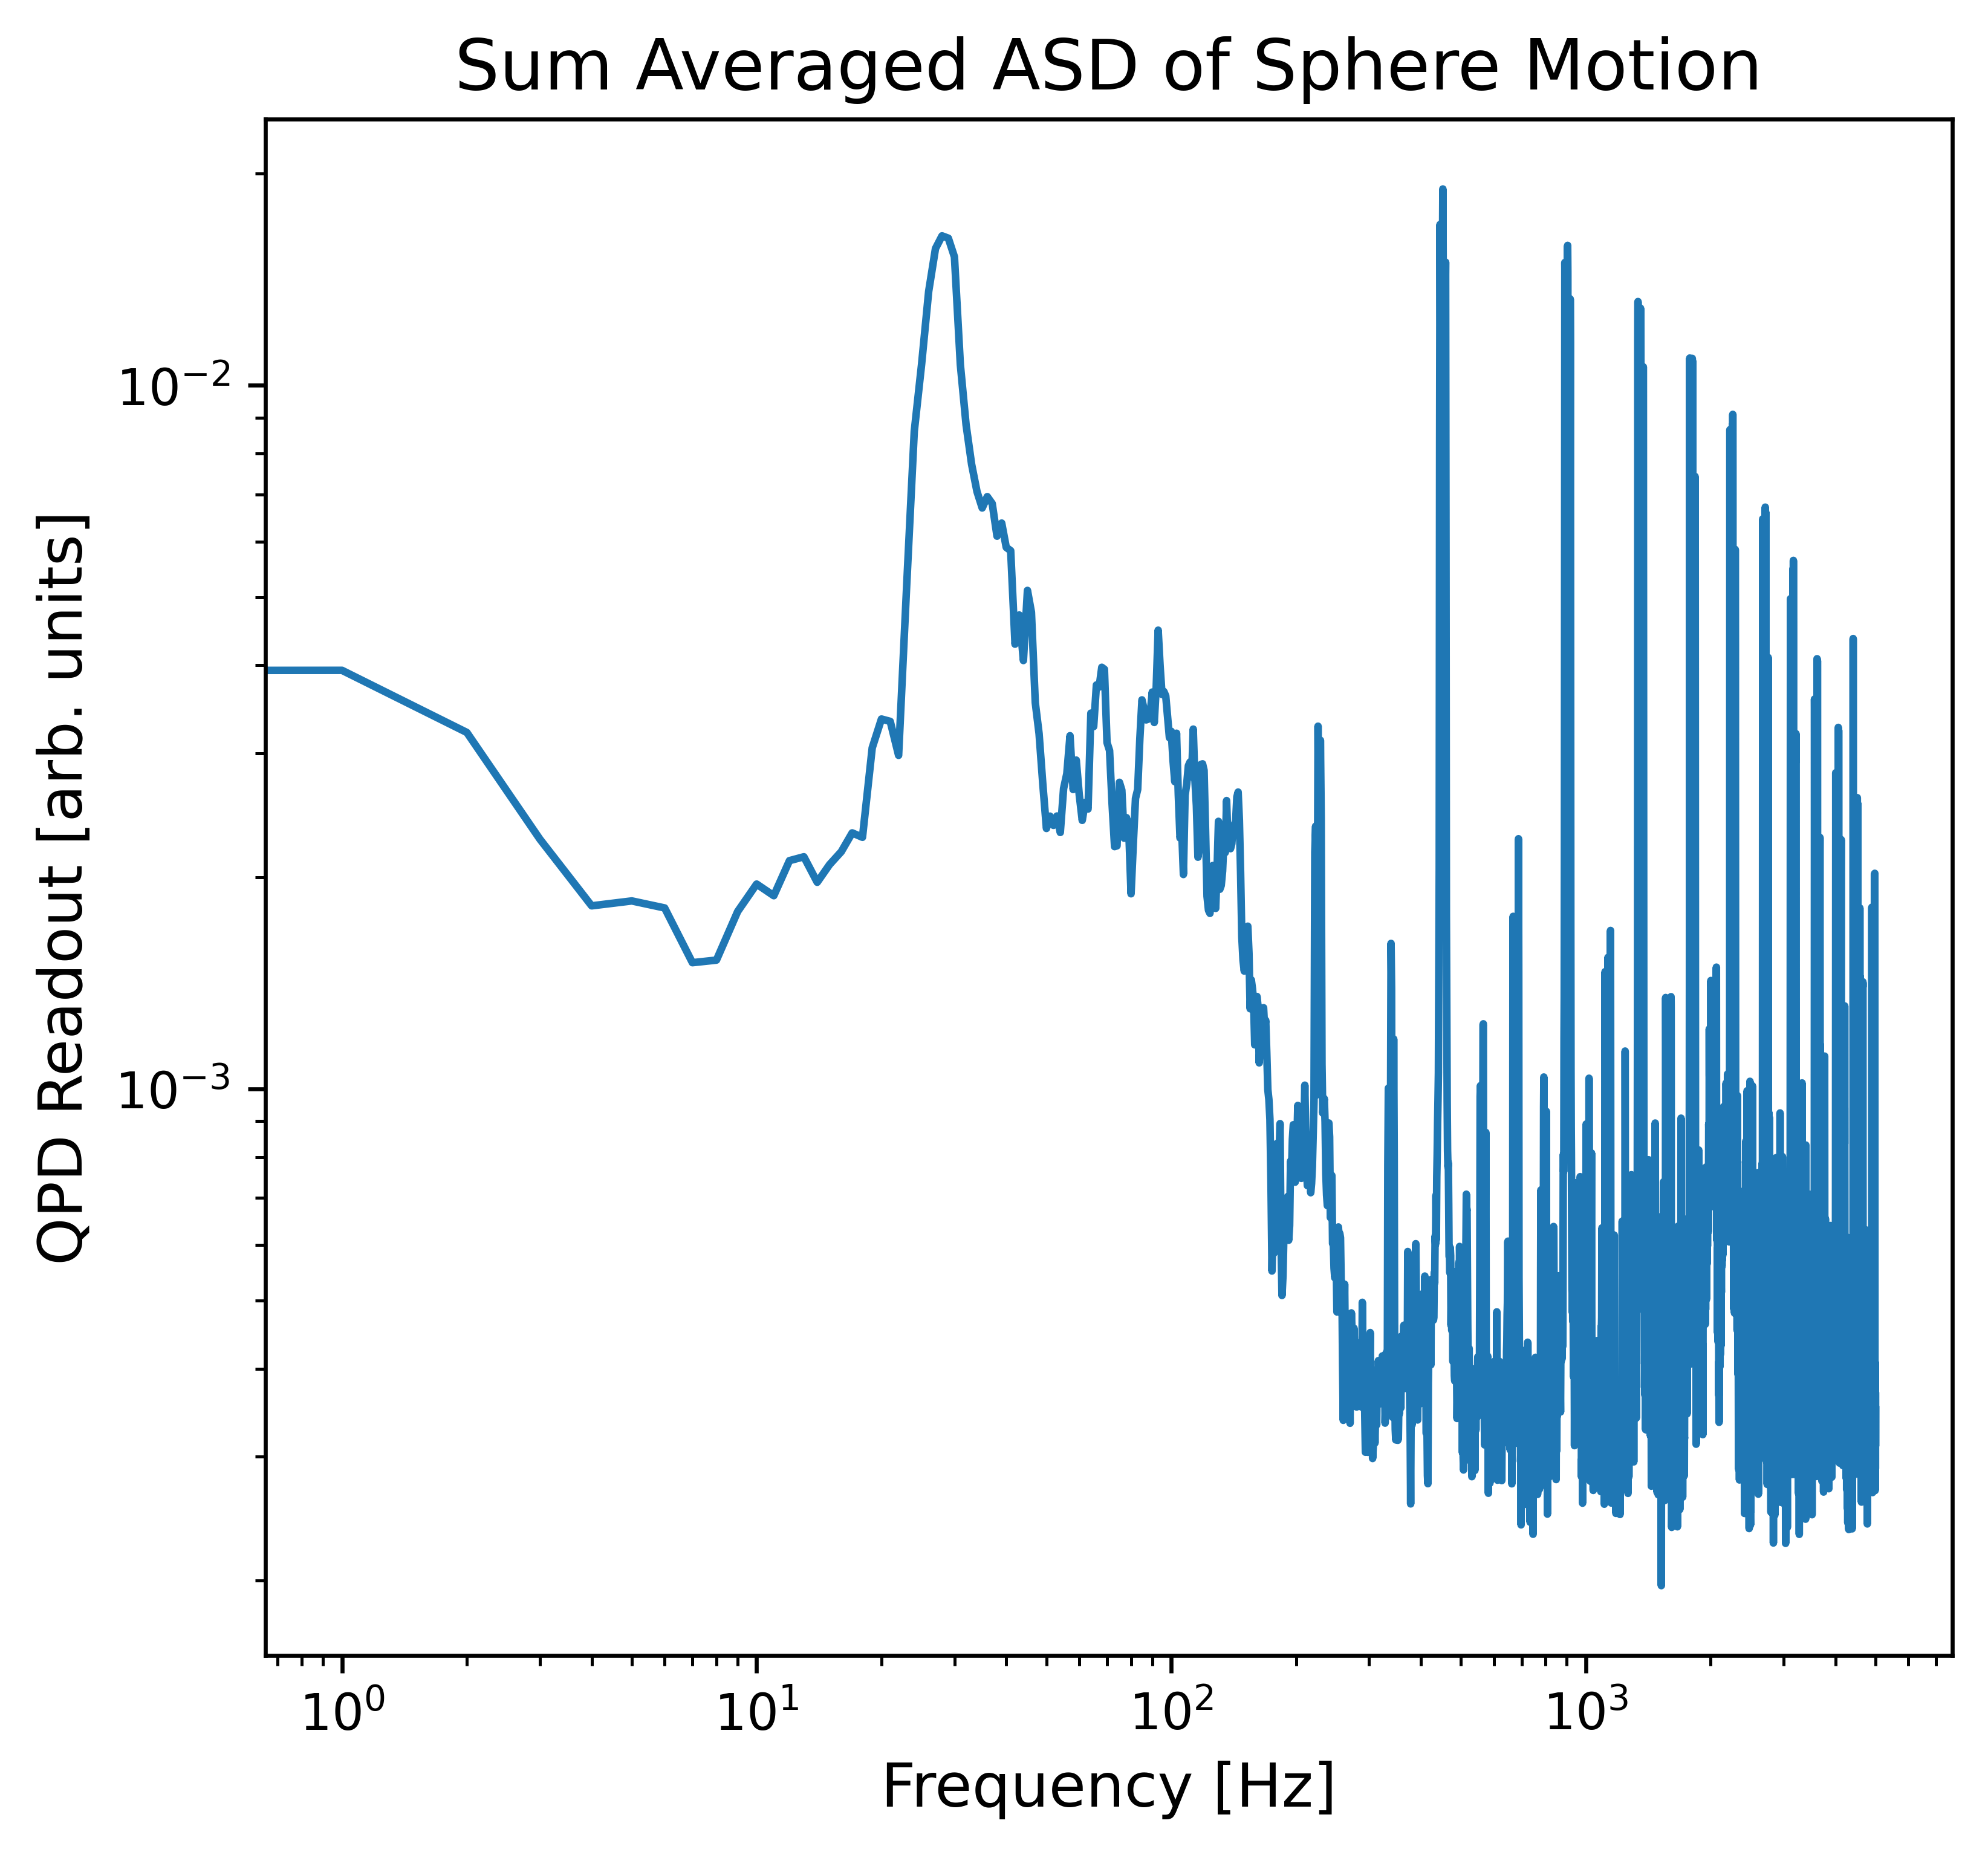

In [15]:
'''
Takes a folder filled with hdf5 data files from the QPD
Plots the PSDs of the spheres averaged over the files
Right now only takes presorted data
'''

import h5py
import numpy as np
import scipy
from scipy.signal import welch
from matplotlib import pyplot as plt
import os
import os
import pandas as pd
import numpy as np
import matplotlib as mpl
from scipy import signal
import copy
import pyfonts


path = r"F:\Lab data\20231121\QPD data of sphere motion\low pressure\point29mbar"

file_name_directory=[]
file_data_directory=[]
file_samplerate_directory=[]

for filename in sorted(os.listdir(path)):
    if filename.endswith(".h5"):
        print(filename)
        file_name_directory.append(os.path.join(path, filename))

        f = h5py.File(os.path.join(path, filename), 'r')
        group = f['beads/data/pos_data']
        data = group[()]
        samplingrate = 1/(group.attrs['Fsamp'])
        
        file_data_directory.append(data)
        file_samplerate_directory.append(samplingrate)
        
        f.close()


xASDlist = [[] for i in range(len(file_data_directory))]
yASDlist = [[] for i in range(len(file_data_directory))]
sumASDlist = [[] for i in range(len(file_data_directory))]
j=0

for item in file_data_directory:
    
    xposlist = np.transpose(item[0,:])
    yposlist = np.transpose(item[1,:])
    sumlist = np.transpose(item[2,:])
    samplerate = file_samplerate_directory[j]
    segmentsize = round(samplerate)
    
    
    xcentered = xposlist - np.mean(xposlist)
    xfreq, xPSD = welch(xcentered, samplerate, 'hann', segmentsize, round(segmentsize/4), None, 'constant', True, 'density', 0,'mean')
    xASDlist[j] = np.sqrt(xPSD)
    


    ycentered = yposlist - np.mean(yposlist)
    yfreq, yPSD = welch(ycentered, samplerate, 'hann', segmentsize, round(segmentsize/4), None, 'constant', True, 'density', 0,'mean')
    yASDlist[j] = np.sqrt(yPSD)
    
    sumcentered = sumlist - np.mean(sumlist)
    sumfreq, sumPSD = welch(sumcentered, samplerate, 'hann', segmentsize, round(segmentsize/4), None, 'constant', True, 'density', 0,'mean')
    sumASDlist[j] = np.sqrt(sumPSD)
    j = j+1
    
xASDavg = np.zeros(len(xASDlist[0]))
yASDavg = np.zeros(len(yASDlist[0]))
sumASDavg = np.zeros(len(sumASDlist[0]))


for i in range(len(xASDlist[0])):
    for j in range(len(xASDlist)):
        xASDavg[i] = xASDavg[i] + xASDlist[j][i]
        yASDavg[i] = yASDavg[i] + yASDlist[j][i]
        sumASDavg[i] = sumASDavg[i] + sumASDlist[j][i]
        
figa, axa = plt.subplots()
figb, axb = plt.subplots()
figc, axc = plt.subplots()

axa.loglog(xfreq, xASDavg)
axb.loglog(yfreq, yASDavg)
axc.loglog(sumfreq, sumASDavg)

    
axa.set_xlabel('Frequency [Hz]')
axb.set_xlabel('Frequency [Hz]')
axc.set_xlabel('Frequency [Hz]')

axa.set_ylabel('QPD Readout [arb. units]')
axb.set_ylabel('QPD Readout [arb. units]')
axc.set_ylabel('QPD Readout [arb. units]')

axa.set_title('Y Averaged ASD of Sphere Motion')
axb.set_title('X Averaged ASD of Sphere Motion')
axc.set_title('Sum Averaged ASD of Sphere Motion')
plt.show()

Text(0, 0.5, 'Camera (m/\\sqrt{Hz})')

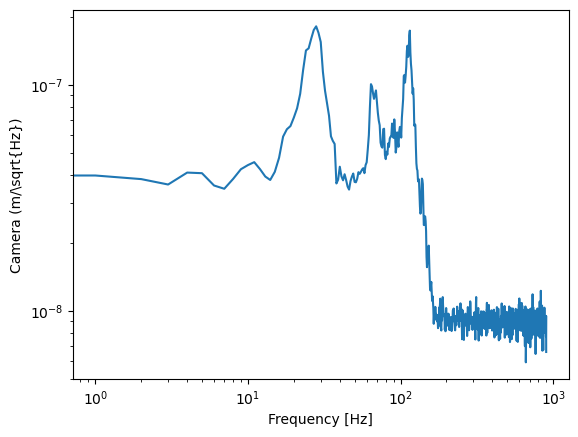

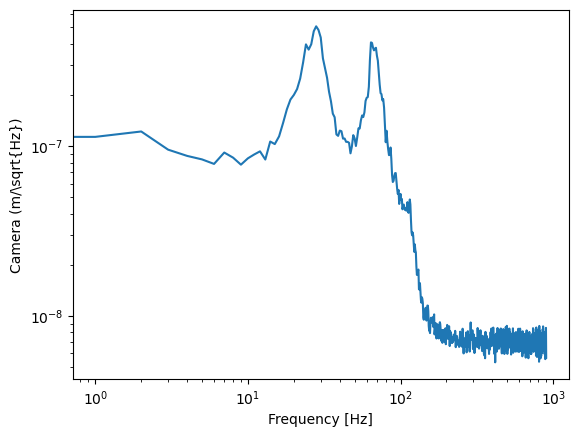

In [2]:
path = r"F:\Lab data\20231121"
filename = "pressurepoint29mbar.h5"
fcam = h5py.File(os.path.join(path, filename), 'r')
fps = 1800
group = fcam['position/Sphere 0']
data = group[()]
fcam.close()

xcam = np.array(data[:,1])
ycam = np.array(data[:,2])
time = np.array(data[:,0])
segmentsize = round(fps)


xcentered = xcam - np.mean(xcam)
xfreqcam, xPSD = welch(xcentered, fps, 'hann', segmentsize, round(segmentsize/4), None, 'constant', True, 'density', 0,'mean')
xASDcam = np.sqrt(xPSD)

ycentered = ycam - np.mean(ycam)
yfreqcam, yPSD = welch(ycentered, fps, 'hann', segmentsize, round(segmentsize/4), None, 'constant', True, 'density', 0,'mean')
yASDcam = np.sqrt(yPSD)

figa, axa = plt.subplots()
figb, axb = plt.subplots()

axa.loglog(xfreqcam, xASDcam)
axb.loglog(yfreqcam, yASDcam)

    
axa.set_xlabel('Frequency [Hz]')
axb.set_xlabel('Frequency [Hz]')

axa.set_ylabel(r"Camera (m/\sqrt{Hz})")
axb.set_ylabel(r"Camera (m/\sqrt{Hz})")


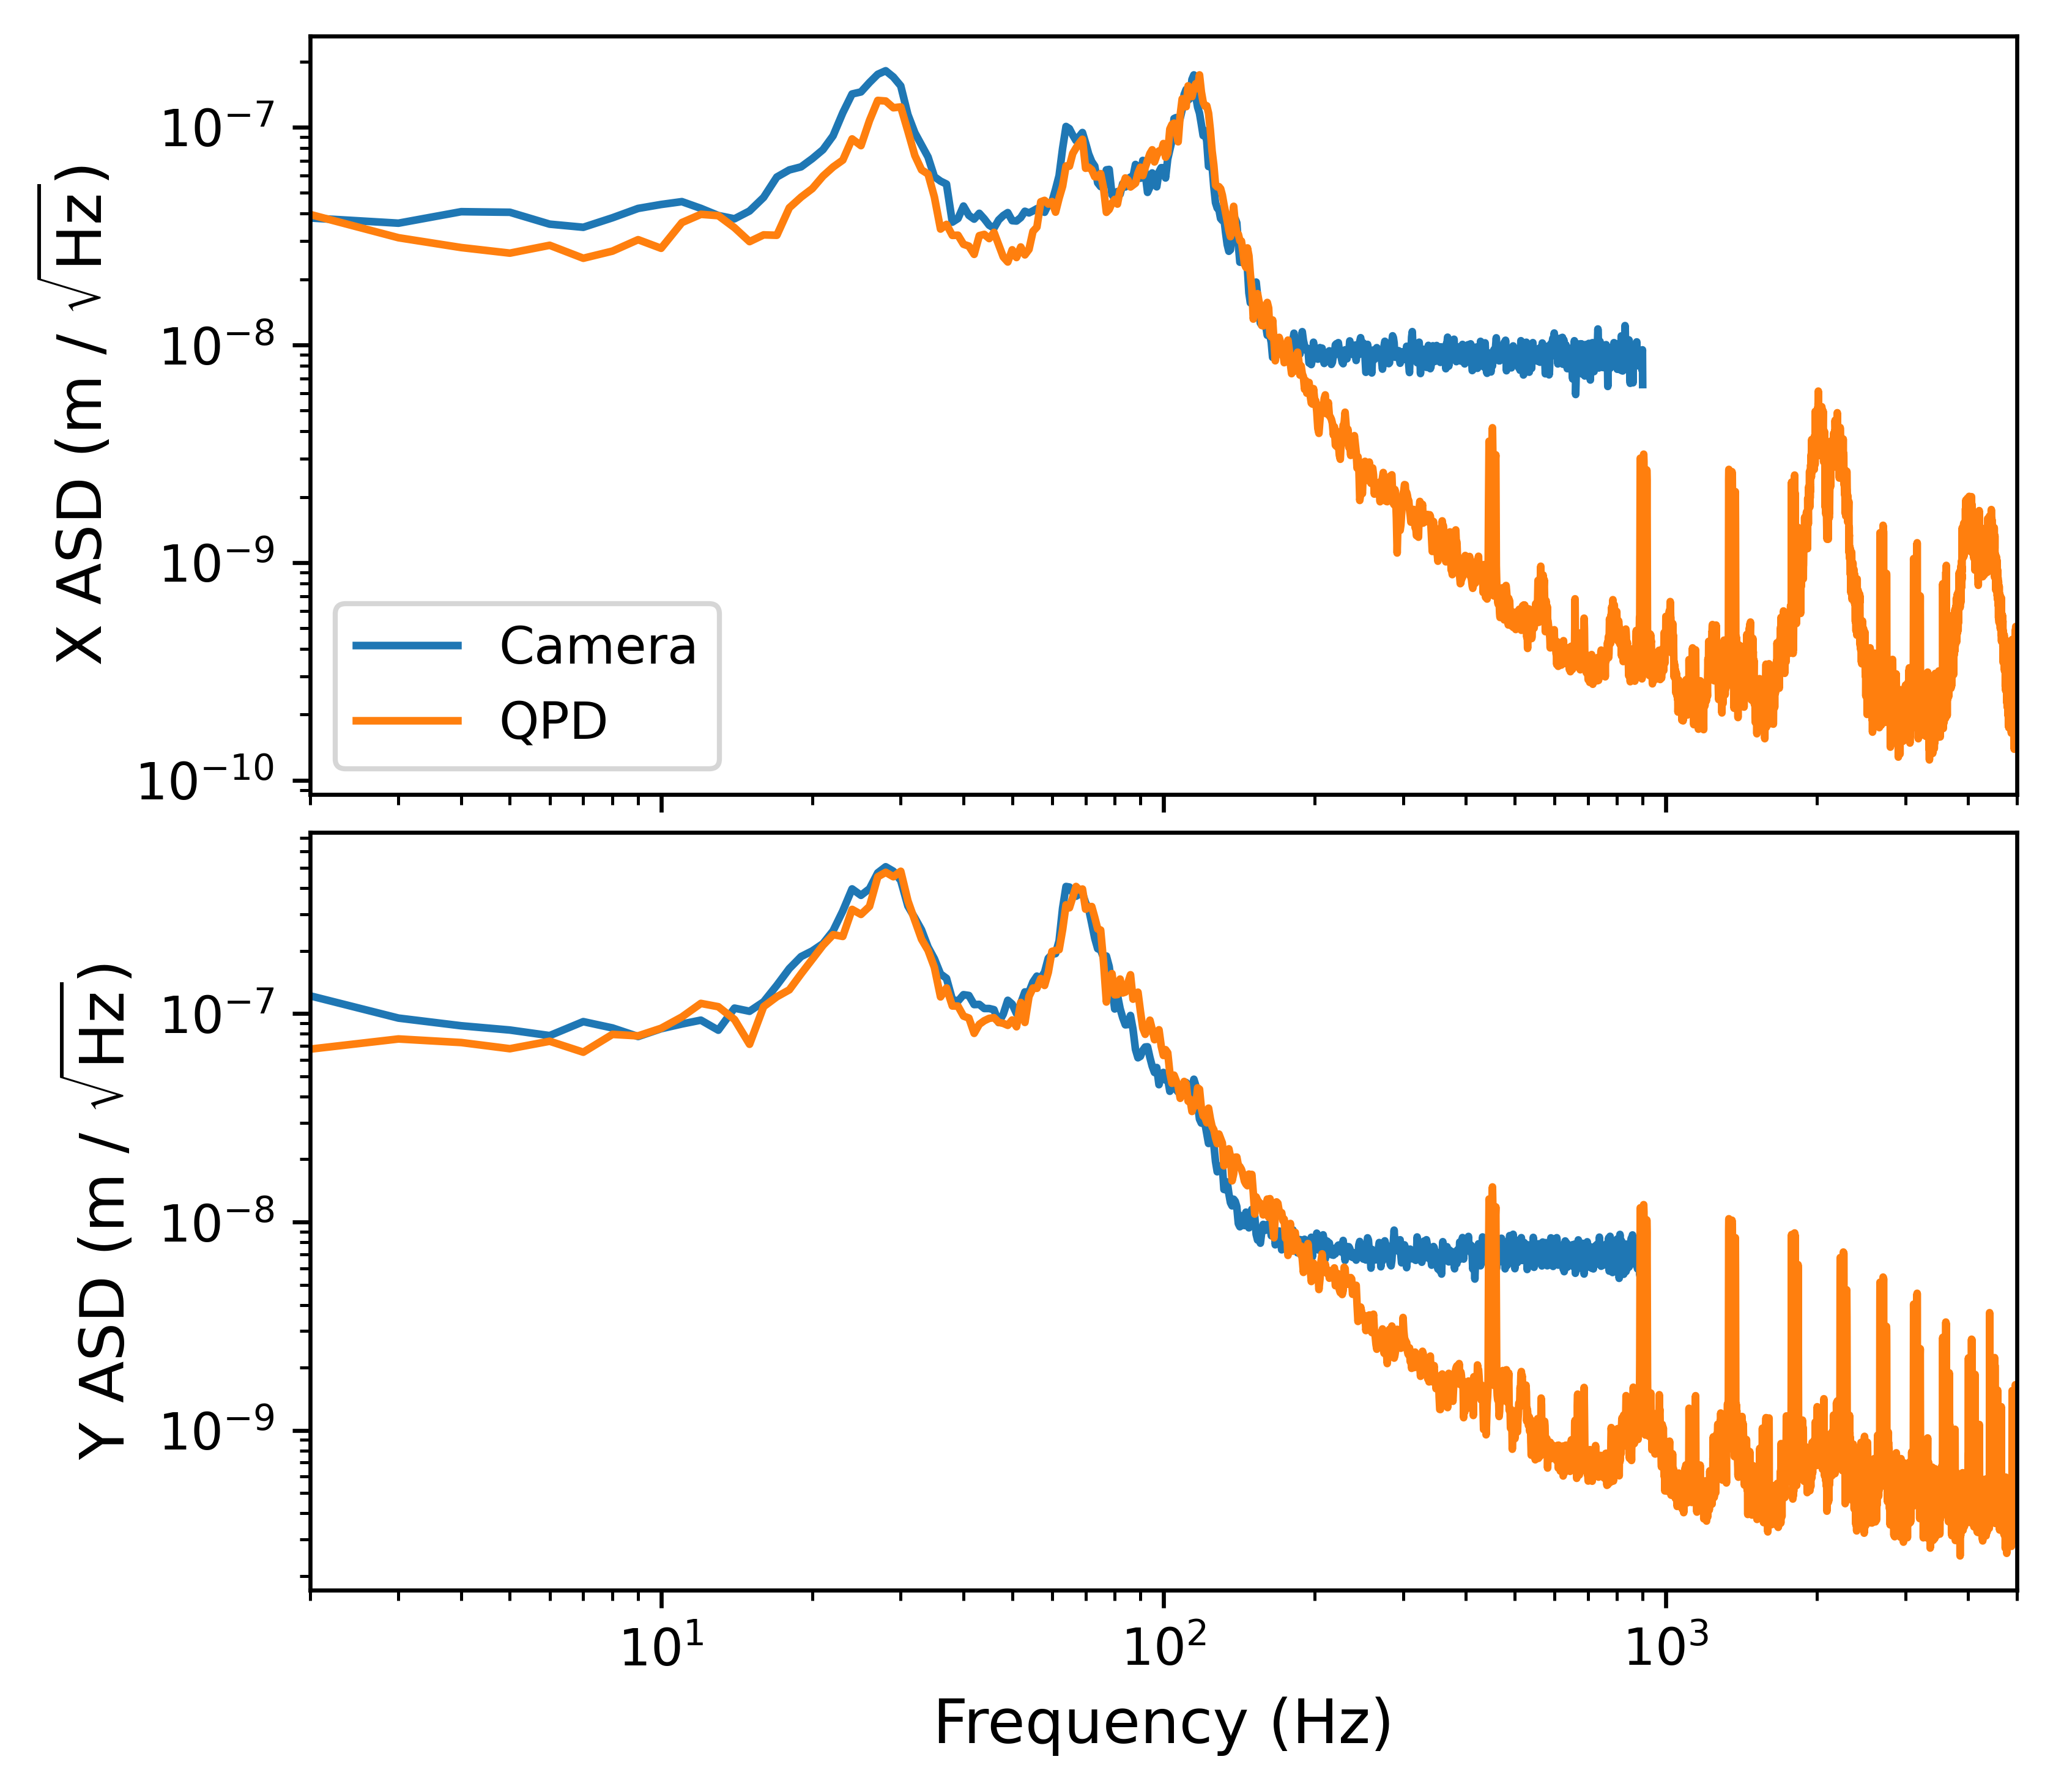

In [19]:
#Set global plotting parameters
mpl.rcParams['agg.path.chunksize'] = 10000
mpl.rcParams['figure.dpi'] = 600


SIZE_DEFAULT = 10
plt.rcParams["font.size"] = SIZE_DEFAULT
plt.rcParams["axes.titlesize"] = SIZE_DEFAULT + 4
plt.rcParams["axes.labelsize"] = SIZE_DEFAULT + 2
plt.rcParams["xtick.labelsize"] = SIZE_DEFAULT
plt.rcParams["ytick.labelsize"] = SIZE_DEFAULT

fig_width = 6  # inches
fig_height = 5.5  # inches
plt.rcParams["figure.figsize"] = (fig_width, fig_height)



fig, ax = plt.subplots(2,1, sharex=True, gridspec_kw={'hspace': 0.05}, figsize=(6, 5.5))
ax[0].loglog(xfreqcam, xASDcam,label='Camera')
ax[1].loglog(yfreqcam, yASDcam,label='Camera')

mask = xfreqcam > 50
xASDcam_max_above50 = np.max(xASDcam[mask])
yASDcam_max_above50 = np.max(yASDcam[mask])

mask = xfreq > 50
xASDmax_above50 = np.max(xASDavg[mask])
yASDmax_above50 = np.max(yASDavg[mask])

xconvert = xASDcam_max_above50/yASDmax_above50
yconvert = yASDcam_max_above50/xASDmax_above50
ax[1].loglog(xfreq, xASDavg*yconvert,label='QPD')
ax[0].loglog(yfreq, yASDavg*xconvert,label='QPD')
ax[0].legend(loc='lower left')
ax[0].set_xlabel('Frequency (Hz)')
ax[1].set_xlabel('Frequency (Hz)')
ax[0].set_ylabel(r"X ASD (m / $\sqrt{\text{Hz}}$)")
ax[1].set_ylabel(r"Y ASD (m / $\sqrt{\text{Hz}}$)")
ax[0].set_xlim(2, 5000)
ax[1].set_xlim(2, 5000)

plt.show()